In [ ]:
!sudo apt-get update
!sudo apt-get install -y texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,960 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,310 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,978 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,844 kB]
Get:14 http://archive.ubu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from scipy.integrate import simpson
from scipy.constants import h, c, k as k_B, e as q
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker

In [ ]:
plt.style.use('default')
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage{libertine} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{bm}',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.color': '#E5E8E8',
    'grid.linestyle': '-',
    'figure.figsize': (4.5, 3.5)
})

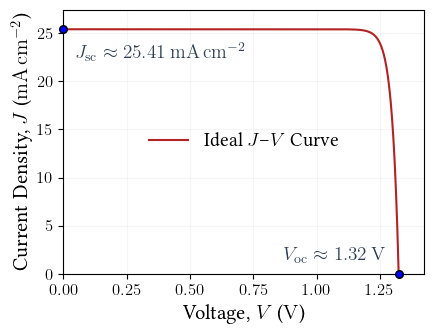

Results for Eg = 1.6 eV:
Short-Circuit Current (Jsc): 25.4114 mA/cm²
Saturation Current (J0):     1.4633e-20 A/m²
Open-Circuit Voltage (Voc):  1.3243 V


In [ ]:
# --- Physical Constants ---
h = 6.626e-34      # Planck constant (J*s)
c = 2.998e8        # Speed of light (m/s)
k = 1.381e-23      # Boltzmann constant (J/K)
q = 1.602e-19      # Elementary charge (C)
T = 300            # Ambient temperature (K)
Eg = 1.6           # Bandgap energy (eV)
Eg_joules = Eg * q # Convert Bandgap to Joules

# --- 1. Solar Spectrum Acquisition (AM1.5G) ---
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TFG/astmg173.xls', skiprows=1)
wavelength_nm = df.iloc[:, 0].values
irradiance_W_m2_nm = df.iloc[:, 2].values

# Calculate Photon Flux
E_photon = (h * c) / (wavelength_nm * 1e-9)
b_lambda = irradiance_W_m2_nm / E_photon

lambda_g_nm = (h * c) / Eg_joules * 1e9
mask = wavelength_nm <= lambda_g_nm

Jsc = q * simpson(b_lambda[mask], wavelength_nm[mask])

# --- 2. Calculate J0 (Radiative Saturation Current Density) ---
def blackbody_flux(E_val, Temp):
    return (2 * np.pi / (h**3 * c**2)) * (E_val**2) / (np.exp(E_val / (k * Temp)) - 1)

E_full = np.linspace(Eg_joules, 4 * q, 2000)
phi_a = blackbody_flux(E_full, T)
J0 = q * simpson(phi_a, E_full)

# --- 3. Generate J-V Characteristics ---
Voc = (k * T / q) * np.log((Jsc / J0) + 1)
V = np.linspace(0, Voc, 500)
J = Jsc - J0 * (np.exp(q * V / (k * T)) - 1)

# --- UNIT CONVERSION (A/m2 to mA/cm2) ---
J_mA = J / 10
Jsc_mA = Jsc / 10

# --- 4. Plotting ---
fig, ax = plt.subplots()

# J-V Curve
label_curve = r'Ideal $J$--$V$ Curve'
ax.plot(V, J_mA, label=label_curve, color='#B22222', lw=1.5, zorder=3)

# Key points
ax.scatter([0, Voc], [Jsc_mA, 0], color='#0000FF', s=30, zorder=4, clip_on=False, edgecolors='black', linewidths=1)

# Annotations
txt_jsc = r'$J_{\mathrm{sc}} \approx ' + f'{Jsc_mA:.2f}' + r'\,\mathrm{mA\,cm^{-2}}$'
txt_voc = r'$V_{\mathrm{oc}} \approx ' + f'{Voc:.2f}' + r'\,\mathrm{V}$'

ax.text(0.05, Jsc_mA - 1.5, txt_jsc, fontsize=14, color='#2C3E50', va='top', ha='left')
ax.text(Voc - 0.05, 1.0, txt_voc, fontsize=14, color='#2C3E50', va='bottom', ha='right')

# Titles and Labels
# ax.set_title(r'\textbf{Ideal $\bm J$--$\bm V$ Characteristic (Shockley--Queisser Limit)}', fontsize=14, pad=15)
ax.set_xlabel(r'Voltage, $V$ ($\mathrm{V}$)', fontsize=15)
ax.set_ylabel(r'Current Density, $J$ ($\mathrm{mA\,cm^{-2}}$)', fontsize=15)

# Fine-tuning limits
ax.set_xlim(0, Voc + 0.1)
ax.set_ylim(0, Jsc_mA + 2)

# Legend
ax.legend(loc='center', fontsize=14, frameon=False)

plt.tight_layout()
plt.savefig('ideal_jv_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Console Results ---
print(f"Results for Eg = {Eg} eV:")
print(f"Short-Circuit Current (Jsc): {Jsc_mA:.4f} mA/cm²")
print(f"Saturation Current (J0):     {J0:.4e} A/m²")
print(f"Open-Circuit Voltage (Voc):  {Voc:.4f} V")

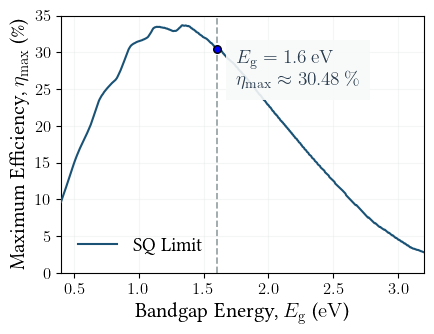

Calculated eta_max at 1.6 eV: 30.48%
Calculated eta_max at 1.12 eV: 33.39%


In [ ]:
# --- Physical Constants & Helper Function ---
h = 6.626e-34       # Planck constant (J s)
c = 2.998e8         # Speed of light (m/s)
k_B = 1.381e-23     # Boltzmann constant (J/K)
q = 1.602e-19       # Elementary charge (C)

def blackbody_flux(E_val, Temp):
    return (2 * np.pi / (h**3 * c**2)) * (E_val**2) / (np.exp(E_val / (k_B * Temp)) - 1)

# --- 1. Thermodynamic Framework & Global Parameters (AM1.5G Standard) ---
T_a = 300            # Ambient temperature (K)

# Total incident power of the AM1.5G standard (~1000 W/m2)
P_in_AM15 = simpson(irradiance_W_m2_nm, wavelength_nm)

def calculate_eta_max_am15g(E_g_eV):
    """Calculates the maximum efficiency eta_max(Ta, Eg) using standard AM1.5G."""
    E_g_J = E_g_eV * q
    lambda_g_nm = (h * c) / E_g_J * 1e9

    # 1. J_sc from AM1.5G solar flux
    mask = wavelength_nm <= lambda_g_nm
    # We use abs() in case the wavelength array is inverted
    J_sc = q * abs(simpson(b_lambda[mask], wavelength_nm[mask]))

    # 2. J_0 from ambient blackbody thermal flux
    E_abs = np.linspace(E_g_J, 6 * q, 2000)
    J_0 = q * simpson(blackbody_flux(E_abs, T_a), E_abs)

    # 3. Voltage and Fill Factor
    V_oc = (k_B * T_a / q) * np.log(1 + J_sc / J_0)
    v_oc = q * V_oc / (k_B * T_a)
    FF = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1)

    # 4. Maximum Efficiency
    eta_max = (J_sc * V_oc * FF) / P_in_AM15
    return eta_max * 100

# --- 2. Data Generation ---
E_g_range = np.linspace(0.4, 3.2, 500)
efficiency_curve = [calculate_eta_max_am15g(val) for val in E_g_range]

# Maximum efficiency for a target 1.6 eV perovskite absorber
target_E_g = 1.6
target_eta_max = calculate_eta_max_am15g(target_E_g)

# Maximum efficiency for a target 1.12 eV perovskite absorber
target_E_g_si = 1.12
target_eta_max_si = calculate_eta_max_am15g(target_E_g_si)


# --- 3. Visualization ---
fig, ax = plt.subplots()

# Main curve
ax.plot(E_g_range, efficiency_curve, label=r'SQ Limit', color='#1A5276', lw=1.5, zorder=3)
# Vertical line and point of interest
ax.axvline(x=target_E_g, color='#7F8C8D', linestyle='--', lw=1.25, alpha=0.8, zorder=1)
ax.scatter([target_E_g], [target_eta_max], color='#0000FF', s=30, zorder=4, clip_on=False, edgecolors='black', linewidths=1)

# Annotation box (escaping \% for LaTeX)
txt_target = (
    r'$E_{\mathrm{g}} = ' + f'{target_E_g:.1f}' + r'\,\mathrm{eV}$' + '\n' +
    r'$\eta_{\mathrm{max}} \approx ' + f'{target_eta_max:.2f}' + r'\,\%$'
)

ax.text(target_E_g + 0.15, target_eta_max - 5.0, txt_target, fontsize=14, color='#2C3E50',
        bbox=dict(boxstyle='square,pad=0.5', fc='#F8F9F9', ec='none', alpha=0.9), zorder=5)

# Titles and Axis Labels
# ax.set_title(r'\textbf{Thermodynamic Efficiency Limit vs. Effective Bandgap}', fontsize=15, pad=15)
ax.set_xlabel(r'Bandgap Energy, $E_{\mathrm{g}}$ ($\mathrm{eV}$)', fontsize=15)
ax.set_ylabel(r'Maximum Efficiency, $\eta_{\mathrm{max}}$ (\%)', fontsize=15)

# Fine-tuning limits
ax.set_xlim(0.4, 3.2)
ax.set_ylim(0, 35)

# Legend
ax.legend(loc='lower left', fontsize=14, frameon=False)

plt.tight_layout()
plt.savefig('sq_limit_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Console Results ---
print(f"Calculated eta_max at {target_E_g} eV: {target_eta_max:.2f}%")
print(f"Calculated eta_max at {target_E_g_si} eV: {target_eta_max_si:.2f}%")

In [ ]:
# --- Physical Constants ---
h = 6.626e-34      # Planck constant (J*s)
c = 2.998e8        # Speed of light (m/s)
k = 1.381e-23      # Boltzmann constant (J/K)
q = 1.602e-19      # Elementary charge (C)
T = 300            # Ambient temperature (K)
Eg = 1.6           # Bandgap energy (eV)
Eg_joules = Eg * q # Convert Bandgap to Joules

# --- 1. Solar Spectrum Acquisition (AM1.5G) ---
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TFG/astmg173.xls', skiprows=1)
wavelength_nm = df.iloc[:, 0].values
irradiance_W_m2_nm = df.iloc[:, 2].values

# Calculate Photon Flux and Photogenerated Current (J_ph)
E_photon = (h * c) / (wavelength_nm * 1e-9)
b_lambda = irradiance_W_m2_nm / E_photon

lambda_g_nm = (h * c) / Eg_joules * 1e9
mask = wavelength_nm <= lambda_g_nm

# J_ph in A/m2
J_ph = q * simpson(b_lambda[mask], wavelength_nm[mask])

# --- 2. Calculate J0 (Radiative Saturation Current Density) ---
def blackbody_flux(E_val, Temp):
    return (2 * np.pi / (h**3 * c**2)) * (E_val**2) / (np.exp(E_val / (k * Temp)) - 1)

E_full = np.linspace(Eg_joules, 4 * q, 2000)
phi_a = blackbody_flux(E_full, T)
J0 = q * simpson(phi_a, E_full) # J0 in A/m2

# --- UNIT CONVERSION (A/m2 to mA/cm2) ---
J_ph_mA = J_ph / 10
J0_mA = J0 / 10

# --- 3. Non-Ideal Diode Configuration (Equation 2.16) ---
m = 1.2 # Ideality factor (>1 for non-ideal)
Vt = (k * T) / q # Thermal voltage

# Calculate approx Voc to define voltage sweep range
Voc_approx = m * Vt * np.log((J_ph_mA / J0_mA) + 1)
V = np.linspace(0, Voc_approx * 1.05, 300)

# Implicit equation to solve using fsolve
def non_ideal_eq(J, V_applied, Jph, J0_val, m_fact, rs, rsh):
    V_drop = V_applied + (J * rs * 1e-3)
    term1 = Jph
    term2 = J0_val * (np.exp(V_drop / (m_fact * Vt)) - 1)
    term3 = V_drop / (rsh * 1e-3) if rsh != np.inf else 0.0
    return term1 - term2 - term3 - J

# Helper function to generate J-V curves
def get_jv_curve(rs_val, rsh_val):
    J_curve = np.zeros_like(V)
    guess = J_ph_mA
    for i, v_point in enumerate(V):
        sol = fsolve(non_ideal_eq, x0=guess, args=(v_point, J_ph_mA, J0_mA, m, rs_val, rsh_val))
        J_curve[i] = sol[0]
        guess = sol[0]
    return J_curve

# =============================================================================
# --- 4. Plotting Figure 1: Impact of Series Resistance (rs) ---
# =============================================================================
fig, ax1 = plt.subplots()

rs_values = [0, 2, 5, 10] # Ohm*cm2
rsh_fixed = np.inf # Ideal parallel resistance

for rs in rs_values:
    J_res = get_jv_curve(rs, rsh_fixed)
    if rs == 0:
        ax1.plot(V, J_res, label=r'$r_{\mathrm{s}} = 0$', color='black', lw=1.5, linestyle='--', zorder=3)
    else:
        ax1.plot(V, J_res, label=rf'$r_{{\mathrm{{s}}}} = {rs}\,\Omega\,\mathrm{{cm}}^2$', lw=1.5, zorder=3)

ax1.set_xlim(0, Voc_approx)
ax1.set_ylim(0, J_ph_mA * 1.05)
ax1.set_xlabel(r'Voltage, $V$ ($\mathrm{V}$)', fontsize=15)
ax1.set_ylabel(r'Current Density, $J$ ($\mathrm{mA\,cm^{-2}}$)', fontsize=15)

ax1.legend(loc='lower left', fontsize=14, frameon=False)
ax1.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig('series_resistance_effect_s.pdf', format='pdf', bbox_inches='tight')
plt.show()

# =============================================================================
# --- 5. Plotting Figure 2: Impact of Shunt Resistance (rsh) ---
# =============================================================================
fig, ax2 = plt.subplots()

rs_fixed = 0.5 # A small, realistic series resistance
rsh_values = [np.inf, 1000, 200, 100] # Ohm*cm2

for rsh in rsh_values:
    J_res = get_jv_curve(rs_fixed, rsh)
    if rsh == np.inf:
        ax2.plot(V, J_res, label=r'$r_{\mathrm{sh}} = \infty$', color='black', lw=1.5, linestyle='--', zorder=3)
    else:
        ax2.plot(V, J_res, label=rf'$r_{{\mathrm{{sh}}}} = {rsh}\,\Omega\,\mathrm{{cm}}^2$', lw=1.5, zorder=3)

# Axis formatting
ax2.set_xlim(0, Voc_approx)
ax2.set_ylim(0, J_ph_mA * 1.05)
ax2.set_xlabel(r'Voltage, $V$ ($\mathrm{V}$)', fontsize=15)
ax2.set_ylabel(r'Current Density, $J$ ($\mathrm{mA\,cm^{-2}}$)', fontsize=15)

ax2.legend(loc='lower left', fontsize=14, frameon=False)
ax2.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig('shunt_resistance_effect_s.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Console Results ---
print(f"Results for Eg = {Eg} eV (Non-Ideal Model, m = {m}):")
print(f"Photogenerated Current (J_ph): {J_ph_mA:.4f} mA/cm²")
print(f"Saturation Current (J0):     {J0_mA:.4e} mA/cm²")
print(f"Approximate Voc:             {Voc_approx:.4f} V")

In [ ]:
# --- Temperature Dependence of SQ Limit for a fixed Bandgap ---

# --- 1. Thermodynamic Framework & Global Parameters ---
E_g_target = 1.6           # Bandgap (eV)
E_g_J = E_g_target * q     # Bandgap in Joules

# Total incident power from AM1.5G standard (~1000 W/m2)
P_in_AM15 = simpson(irradiance_W_m2_nm, wavelength_nm)

# Calculate J_sc (Constant for a fixed Eg, independent of cell temperature)
lambda_g_nm = (h * c) / E_g_J * 1e9
mask = wavelength_nm <= lambda_g_nm
E_photon = (h * c) / (wavelength_nm * 1e-9)
b_lambda = irradiance_W_m2_nm / E_photon
# Abs() in case wavelength array is inverted
J_sc = q * abs(simpson(b_lambda[mask], wavelength_nm[mask]))

def calculate_eta_max_T(T_cell):
    """Calculates the maximum efficiency eta_max(T, Eg=1.6eV) using standard AM1.5G."""
    # J_0 from cell's blackbody thermal flux at temperature T_cell
    E_abs = np.linspace(E_g_J, 6 * q, 2000)
    J_0 = q * simpson(blackbody_flux(E_abs, T_cell), E_abs)

    # Voltage and Fill Factor (Temperature dependent)
    V_oc = (k_B * T_cell / q) * np.log(1 + J_sc / J_0)
    v_oc = q * V_oc / (k_B * T_cell)

    # Fill factor approximation
    FF = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1)

    # Maximum Efficiency
    eta_max = (J_sc * V_oc * FF) / P_in_AM15
    return eta_max * 100

# --- 2. Data Generation ---
# Define a reasonable operating temperature range (8 C to 50 C)
T_range = np.linspace(281.15, 323.15, 500) # Kelvin
efficiency_T_curve = [calculate_eta_max_T(T) for T in T_range]

# Reference point at standard ambient temperature (300 K)
target_T = 300
target_eta_T = calculate_eta_max_T(target_T)

# --- Visualization: Efficiency vs Temperature in Celsius ---

# 1. Define the range in Kelvin for internal calculations
T_kelvin_range = T_range
efficiency_T_curve = [calculate_eta_max_T(T) for T in T_kelvin_range]

# 2. Convert the range to Celsius only for the X-axis of the plot
T_celsius_range = T_kelvin_range - 273.15

# Reference point at standard ambient temperature (25ºC / 298.15K)
target_T_C = 25
target_T_K = target_T_C + 273.15
target_eta_T = calculate_eta_max_T(target_T_K)

# --- 3. Plotting ---
fig, ax = plt.subplots()

# Main curve (X in Celsius)
ax.plot(T_celsius_range, efficiency_T_curve, label=rf'SQ Limit ($E_{{\mathrm{{g}}}} = {E_g_target}\,\mathrm{{eV}}$)', color='#D35400', lw=1.5, zorder=3)

# Vertical line and point at 25ºC
ax.axvline(x=target_T_C, color='#7F8C8D', linestyle='--', lw=1.25, alpha=0.8, zorder=1)
ax.scatter([target_T_C], [target_eta_T], color='#0000FF', s=35, zorder=4, clip_on=False, edgecolors='black', linewidths=1)

# Annotation box with the ºC degree symbol
txt_target_T = (
    r'$T = ' + f'{target_T_C}' + r'\,^\circ\mathrm{C}$' + '\n' +
    r'$\eta_{\mathrm{max}} \approx ' + f'{target_eta_T:.2f}' + r'\,\%$'
)

ax.text(target_T_C + 5, target_eta_T + 1.5, txt_target_T, fontsize=14, color='#2C3E50',
        bbox=dict(boxstyle='square,pad=0.5', fc='#F8F9F9', ec='none', alpha=0.9), zorder=5)

# Titles and Axis Labels (Using Celsius)
ax.set_xlabel(r'Cell Temperature ($^\circ\mathrm{C}$)', fontsize=15)
ax.set_ylabel(r'Maximum Efficiency, $\eta_{\mathrm{max}}$ (\%)', fontsize=15)

# Fine-tuning limits
ax.set_xlim(T_celsius_range[0], T_celsius_range[-1])
ax.set_ylim(min(efficiency_T_curve) - 2, max(efficiency_T_curve) + 5)

# Legend
ax.legend(loc='upper right', fontsize=14, frameon=False)

plt.tight_layout()
plt.savefig('sq_limit_vs_temperature_Celsius.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Console Results ---
print(f"Maximum efficiency at {target_T_C}°C: {target_eta_T:.2f}%")

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Features')
def get_cell_df(cell_id):
  cell_df = df[df['cell_id'] == cell_id]
  if cell_id == 0:
    cell = 'M0'
  else:
    cell = 'P12'
  return cell_df, cell

def blackbody_flux(E_val, Temp):
    return (2 * np.pi / (h**3 * c**2)) * (E_val**2) / (np.exp(E_val / (k_B * Temp)) - 1)

def calculate_eta_max_T(T_cell_K, J_sc_ideal, E_g_J, P_in_AM15):
    E_abs = np.linspace(E_g_J, 6 * q, 2000)
    J_0 = q * simpson(blackbody_flux(E_abs, T_cell_K), E_abs)

    V_oc = (k_B * T_cell_K / q) * np.log(1 + J_sc_ideal / J_0)
    v_oc = q * V_oc / (k_B * T_cell_K)
    FF = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1)

    eta_max = (J_sc_ideal * V_oc * FF) / P_in_AM15
    return eta_max * 100

def check_pwr_vs_var_with_theory(cell_id, power='pce', variable='DeviceTemp',
                                 min_gci=0, min_irradiance_mwcm2=0, min_power=0,
                                 E_g_target=1.6):

    # Retrieve data
    cell_df, cell = get_cell_df(cell_id=cell_id)

    mask_clear = (cell_df['gci'] > min_gci) & \
                 (cell_df['irradiance_30_degrees_mwcm2'] > min_irradiance_mwcm2) & \
                 (cell_df[power] > min_power)

    if variable not in cell_df.columns:
        print(f"Error: Variable '{variable}' does not exist in the DataFrame.")
        return

    data_x = cell_df.loc[mask_clear, variable]
    data_y = cell_df.loc[mask_clear, power]

    is_pce_vs_temp = ('pce' in power.lower()) and (variable == 'DeviceTemp')

    # --- NAME AND UNIT CONFIGURATION ---
    if 'pce' in power.lower():
        metric_name = "PCE"
        unit_y = r"\%"
        heatmap_cmap = 'magma'
    else:
        metric_name = "STC Power"
        unit_y = r"\mathrm{mW/cm^2}"
        heatmap_cmap = 'mako'

    if variable == 'DeviceTemp':
        var_name = "Device Temperature"
        unit_x = r"^\circ\mathrm{C}"
        analysis_type = "Physical Thermal Behavior"
    elif variable == 'Humidity':
        var_name = "Humidity"
        unit_x = r"\%"
        analysis_type = "Environmental Dependency (Humidity)"
    else:
        var_name = variable
        unit_x = "units"
        analysis_type = f"{variable} Dependency"

    print(f"--- Starting {analysis_type} for: {cell} ---")

    # Plots (Single panel)
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6)) # Adjusted size for a single plot

    # --- PLOT: HEATMAP ---
    sns.histplot(
        x=data_x, y=data_y, bins=50, cmap=heatmap_cmap, cbar=True,
        cbar_kws={'label': 'Density (Count)', 'pad': 0.15}, ax=ax
    )

    ax.set_title(r'\textbf{Density Distribution (Heatmap)}', fontsize=12)
    ax.set_xlabel(rf'{var_name} (${unit_x}$)')
    ax.set_ylabel(rf'Experimental {metric_name} (${unit_y}$)')

    # --- THEORETICAL OVERLAY ---
    if is_pce_vs_temp:
        E_g_J = E_g_target * q
        P_in_AM15 = simpson(irradiance_W_m2_nm, wavelength_nm)

        lambda_g_nm = (h * c) / E_g_J * 1e9
        mask_sq = wavelength_nm <= lambda_g_nm
        E_photon = (h * c) / (wavelength_nm * 1e-9)
        b_lambda = irradiance_W_m2_nm / E_photon
        J_sc_ideal = q * abs(simpson(b_lambda[mask_sq], wavelength_nm[mask_sq]))

        x_min, x_max = data_x.min(), data_x.max()
        T_celsius_range = np.linspace(x_min, x_max, 100)
        T_kelvin_range = T_celsius_range + 273.15

        efficiency_T_curve = [calculate_eta_max_T(T_k, J_sc_ideal, E_g_J, P_in_AM15) for T_k in T_kelvin_range]

        # Secondary axis for the theoretical curve
        ax_twin = ax.twinx()
        ax_twin.plot(T_celsius_range, efficiency_T_curve, color='#D35400', lw=2.5, linestyle='--',
                     label=rf'SQ Limit ($E_{{\mathrm{{g}}}} = {E_g_target}\,\mathrm{{eV}}$)')

        ax_twin.set_ylabel(rf'Theoretical Efficiency Limit (${unit_y}$)', color='#D35400', fontweight='bold')
        ax_twin.tick_params(axis='y', labelcolor='#D35400')
        ax_twin.grid(False) # Avoid double grid

        # Legend only for the curve (the heatmap already has its color bar)
        ax_twin.legend(loc='upper right', frameon=True)

    plt.suptitle(rf'\textbf{{{analysis_type}: {cell}}}', fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Visualization completed for {cell}.")

In [ ]:
check_pwr_vs_var_with_theory(cell_id=0)
print('\n')
check_pwr_vs_var_with_theory(cell_id=1)

In [ ]:
def plot_combined_pwr_vs_var(power='pce', variable='DeviceTemp',
                             min_gci=0, min_irradiance_mwcm2=0, min_power=0,
                             E_g_target=1.6):
    # --- NAME AND UNIT CONFIGURATION ---
    is_pce_vs_temp = ('pce' in power.lower()) and (variable == 'DeviceTemp')

    if 'pce' in power.lower():
        metric_name = "PCE"
        unit_y = r"\%"
        heatmap_cmap = 'magma'
    else:
        metric_name = "STC Power"
        unit_y = r"\mathrm{mW/cm^2}"
        heatmap_cmap = 'mako'

    if variable == 'DeviceTemp':
        var_name = "Device Temperature"
        unit_x = r"^\circ\mathrm{C}"
        analysis_type = "Physical Thermal Behavior"
    elif variable == 'Humidity':
        var_name = "Humidity"
        unit_x = r"\%"
        analysis_type = "Environmental Dependency (Humidity)"
    else:
        var_name = variable
        unit_x = "units"
        analysis_type = f"{variable} Dependency"

    print(f"--- Starting {analysis_type} for M0 and P12 ---")

    # --- FIGURE CREATION WITH GRIDSPEC ---
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 8))

    # GridSpec with 3 columns: [Plot 1, Plot 2, Colorbar]
    # width_ratios ensures the first two are 1 (equal) and the third is very thin (0.05)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.2)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    cbar_ax = fig.add_subplot(gs[0, 2]) # Exclusive axis for the colorbar

    axes = [ax0, ax1]
    cells_to_plot = [0, 1]
    twin_axes = []

    for idx, cell_id in enumerate(cells_to_plot):
        ax = axes[idx]

        # Retrieve data
        cell_df, cell = get_cell_df(cell_id=cell_id)

        mask_clear = (cell_df['gci'] > min_gci) & \
                     (cell_df['irradiance_30_degrees_mwcm2'] > min_irradiance_mwcm2) & \
                     (cell_df[power] > min_power)

        if variable not in cell_df.columns:
            print(f"Error: Variable '{variable}' does not exist in the DataFrame.")
            return

        data_x = cell_df.loc[mask_clear, variable]
        data_y = cell_df.loc[mask_clear, power]

        # --- PLOT: HEATMAP ---
        show_cbar = (idx == 1)

        sns.histplot(
            x=data_x, y=data_y, bins=50, cmap=heatmap_cmap,
            cbar=show_cbar,
            cbar_ax=cbar_ax if show_cbar else None, # Pass the axis we created
            cbar_kws={'label': 'Density (Count)', 'pad': 0.2} if show_cbar else None,
            ax=ax
        )

        ax.set_title(rf'\textbf{{{cell} - Density Distribution}}', fontsize=14)
        ax.set_xlabel(rf'{var_name} (${unit_x}$)')

        # Cleaning up the central Y axes
        if idx == 0:
            ax.set_ylabel(rf'Experimental {metric_name} (${unit_y}$)')
        else:
            ax.tick_params(labelleft=False) # Hide numbers on the left side of P12
            ax.set_ylabel('')

        # --- THEORETICAL OVERLAY ---
        if is_pce_vs_temp:
            E_g_J = E_g_target * q
            P_in_AM15 = simpson(irradiance_W_m2_nm, wavelength_nm)

            lambda_g_nm = (h * c) / E_g_J * 1e9
            mask_sq = wavelength_nm <= lambda_g_nm
            E_photon = (h * c) / (wavelength_nm * 1e-9)
            b_lambda = irradiance_W_m2_nm / E_photon
            J_sc_ideal = q * abs(simpson(b_lambda[mask_sq], wavelength_nm[mask_sq]))

            x_min, x_max = data_x.min(), data_x.max()
            T_celsius_range = np.linspace(x_min, x_max, 100)
            T_kelvin_range = T_celsius_range + 273.15

            efficiency_T_curve = [calculate_eta_max_T(T_k, J_sc_ideal, E_g_J, P_in_AM15) for T_k in T_kelvin_range]

            # Secondary axis for the theoretical curve
            ax_twin = ax.twinx()
            twin_axes.append(ax_twin)

            ax_twin.plot(T_celsius_range, efficiency_T_curve, color='#D35400', lw=2.5, linestyle='--',
                         label=rf'SQ Limit ($E_{{\mathrm{{g}}}} = {E_g_target}\,\mathrm{{eV}}$)')

            ax_twin.tick_params(axis='y', labelcolor='#D35400')
            ax_twin.grid(False)

            # Configuration of the twin axes (theoretical)
            if idx == 0:
                ax_twin.set_yticklabels([])
            else:
                ax_twin.set_ylabel(fr'\textbf{{Theo. Limit}} $\eta_{{\mathrm{{max}}}}$ (${unit_y}$)', color='#D35400', fontweight='bold')
                ax_twin.legend(loc='upper right', frameon=True)

    # Equalize theoretical scales
    if twin_axes and len(twin_axes) == 2:
        twin_axes[0].sharey(twin_axes[1])

    # plt.suptitle(rf'\textbf{{{analysis_type}: M0 vs P12}}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print("Visualization completed.")

plot_combined_pwr_vs_var()

In [ ]:
jv_params_wide = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/JV/jv_params_wide.parquet')

In [ ]:
jv_params_wide

,index,id_curve,cell_id,label_curve,ff_fwd,ff_rev,jsc_fwd,jsc_rev,p_mpp_fwd,p_mpp_rev,time_fwd,time_rev,v_mpp_fwd,v_mpp_rev,voc_fwd,voc_rev,time_avg
0,0,1,0,0,0.303823,0.467210,4.844088,4.955645,1.076887,1.770396,2025-09-22 18:36:57.887849984,2025-09-22 18:36:45.555318016,378.26,485.52,732.548,742.336,2025-09-22 18:36:51.721584128
1,1,2,0,0,0.301464,0.475155,4.511007,4.511007,0.984776,1.644996,2025-09-22 18:41:58.308773888,2025-09-22 18:41:45.976614912,397.44,521.61,723.854,750.842,2025-09-22 18:41:52.142694400
2,2,3,0,0,0.316181,0.494997,3.951695,3.951409,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392
3,3,4,0,0,0.327281,0.513709,3.391087,3.390597,0.769996,1.298696,2025-09-22 18:51:59.142903040,2025-09-22 18:51:46.811891968,383.40,479.18,689.852,726.628,2025-09-22 18:51:52.977397504
4,4,5,0,0,0.299184,0.465992,3.394280,3.394280,0.686152,1.159819,2025-09-22 18:56:59.524162048,2025-09-22 18:56:47.193059072,371.92,493.55,676.998,721.136,2025-09-22 18:56:53.358610432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11368,11368,28531,1,3,0.294048,0.389994,1.138434,1.138434,0.192599,0.284018,2025-11-11 17:05:46.143228928,2025-11-11 17:05:33.819033088,350.35,455.43,560.112,633.472,2025-11-11 17:05:39.981131008
11369,11369,28532,1,3,0.441940,0.616564,0.569632,0.569632,0.127659,0.204509,2025-11-11 17:10:46.670853120,2025-11-11 17:10:34.352898048,300.08,431.55,496.538,578.350,2025-11-11 17:10:40.511875584
11370,11370,28533,1,0,0.419644,0.494728,0.569840,0.569840,0.107627,0.158727,2025-11-11 17:15:47.214900992,2025-11-11 17:15:34.895695872,288.74,417.54,457.388,554.244,2025-11-11 17:15:41.055298560
11371,11371,28534,1,3,0.345758,0.434548,0.570047,0.570047,0.081403,0.123325,2025-11-11 17:20:47.763085056,2025-11-11 17:20:35.437742080,274.73,381.40,396.376,504.616,2025-11-11 17:20:41.600413696


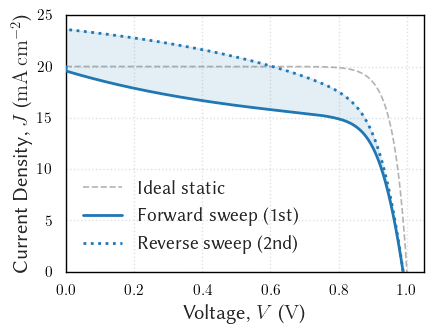

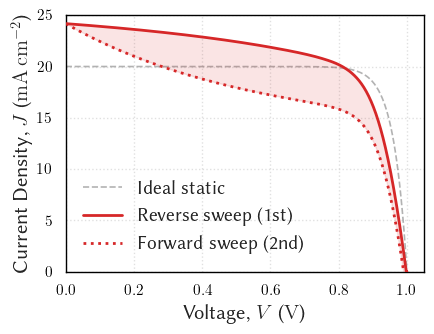

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp

# ──────────────────────────────────────────────────────────────────────────────
# 1. PARAMETERS
# ──────────────────────────────────────────────────────────────────────────────
J_ph_mA  = 20.0; J_ph = J_ph_mA * 1e-3
J_0_mA   = 1.2e-10; J_0 = J_0_mA * 1e-3
n_id     = 1.5; Vt = 0.0258; r_s = 2.0; r_sh = 1000.0
c_0      = 0.1 * 1e-6; C_ion = 10.0 * 1e-3; tau = 1.0
V_oc_val = 1.0; scan_rate = 0.5; t_half = V_oc_val / scan_rate

# ──────────────────────────────────────────────────────────────────────────────
# 2. ODE SYSTEM & SOLVER FUNCTION
# ──────────────────────────────────────────────────────────────────────────────
def dem_ode(t, y, v_func):
    J, P_nl = y
    V, dV_dt = v_func(t)
    V_int = V + J * r_s
    P_inf = C_ion * V_int
    dPnl_dt = (P_inf - P_nl) / tau
    J_diode = J_0 * (np.exp(V_int / (n_id * Vt)) - 1.0)
    rhs = J_diode + (r_s/r_sh + 1.0)*J + V/r_sh + c_0*dV_dt + dPnl_dt - J_ph
    return [-rhs / (r_s * c_0), dPnl_dt]

def run_simulation(v_waveform, y0):
    t_span = (0.0, 2.0 * t_half)
    t_eval = np.linspace(0, 2.0 * t_half, 2000)
    sol = solve_ivp(dem_ode, t_span, y0, args=(v_waveform,), method="Radau", t_eval=t_eval, rtol=1e-8)
    v_out = np.array([v_waveform(t)[0] for t in sol.t])
    return v_out, sol.y[0] * 1e3, sol.t

# ──────────────────────────────────────────────────────────────────────────────
# 3. WAVEFORMS
# ──────────────────────────────────────────────────────────────────────────────
def v_forward_start(t):
    if t <= t_half: return scan_rate * t, scan_rate
    else: return V_oc_val - scan_rate * (t - t_half), -scan_rate

def v_reverse_start(t):
    if t <= t_half: return V_oc_val - scan_rate * t, -scan_rate
    else: return scan_rate * (t - t_half), scan_rate

# ──────────────────────────────────────────────────────────────────────────────
# 4. EXECUTION
# ──────────────────────────────────────────────────────────────────────────────
# Sim 1: Starts at 0V (Forward) -> P_nl0 = 0
v1, j1, t1 = run_simulation(v_forward_start, [J_ph_mA * 1e-3, 0.0])
# Sim 2: Starts at Voc (Reverse) -> P_nl0 = C_ion * Voc
v2, j2, t2 = run_simulation(v_reverse_start, [0.0, C_ion * V_oc_val])

# ── Calculation of the ideal analytical curve ─────────────────────────────────
V_ideal = np.linspace(0, 1.05, 500)
J_ideal = J_ph_mA - J_0_mA * (np.exp(V_ideal / (n_id * Vt)) - 1.0)

FWD_CLR = "tab:blue"
REV_CLR = "tab:red"
IDEAL_CLR = "gray"

# =============================================================================
# --- 5. Plotting Figure 1: Forward Start Loop ---
# =============================================================================
fig1, ax1 = plt.subplots()

ax1.plot(V_ideal, J_ideal, color=IDEAL_CLR, linestyle='--', lw=1.2, alpha=0.6, label='Ideal static', zorder=1)

ax1.fill(v1, j1, color=FWD_CLR, alpha=0.12, zorder=2)

ax1.plot(v1[t1 <= t_half], j1[t1 <= t_half], color=FWD_CLR, lw=2.0, label='Forward sweep (1st)', zorder=4)
ax1.plot(v1[t1 > t_half], j1[t1 > t_half], color=FWD_CLR, lw=2.0, linestyle=':', label='Reverse sweep (2nd)', zorder=4)

ax1.set_xlim(0, 1.05)
ax1.set_ylim(0, 25)
ax1.set_xlabel(r'Voltage, $V$ ($\mathrm{V}$)', fontsize=15)
ax1.set_ylabel(r'Current Density, $J$ ($\mathrm{mA\,cm^{-2}}$)', fontsize=15)

ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5))

for spine in ax1.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax1.tick_params(axis='both', colors='black', direction='out')

ax1.legend(loc='lower left', fontsize=14, frameon=False)
ax1.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig('hysteresis_forward_start.pdf', format='pdf', bbox_inches='tight')
plt.show()

# =============================================================================
# --- 6. Plotting Figure 2: Reverse Start Loop ---
# =============================================================================
fig2, ax2 = plt.subplots()

ax2.plot(V_ideal, J_ideal, color=IDEAL_CLR, linestyle='--', lw=1.2, alpha=0.6, label='Ideal static', zorder=1)

ax2.fill(v2, j2, color=REV_CLR, alpha=0.12, zorder=2)

ax2.plot(v2[t2 <= t_half], j2[t2 <= t_half], color=REV_CLR, lw=2.0, label='Reverse sweep (1st)', zorder=4)
ax2.plot(v2[t2 > t_half], j2[t2 > t_half], color=REV_CLR, lw=2.0, linestyle=':', label='Forward sweep (2nd)', zorder=4)

ax2.set_xlim(0, 1.05)
ax2.set_ylim(0, 25)
ax2.set_xlabel(r'Voltage, $V$ ($\mathrm{V}$)', fontsize=15)
ax2.set_ylabel(r'Current Density, $J$ ($\mathrm{mA\,cm^{-2}}$)', fontsize=15)

ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))

 for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax2.tick_params(axis='both', colors='black', direction='out')

ax2.legend(loc='lower left', fontsize=14, frameon=False)
ax2.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig('hysteresis_reverse_start.pdf', format='pdf', bbox_inches='tight')
plt.show()